In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker 
from matplotlib.ticker import MaxNLocator
import warnings

warnings.filterwarnings('ignore')
pd.options.display.float_format = '{:,.0f}'.format

# Characterizing SLCP offsetting in the voluntary carbon market

The temperature dynamics we characterized for the California program apply anywhere offsetting relies on short-lived climate pollutants (SLCPs). The picture is squishier in the voluntary carbon market (VCM), since offsets in the VCM don't justify emissions that polluters would otherwise have a regulatory obligation to reduce, but we can still characterize the role SLCP crediting plays in the VCM and how that role is changing.

This notebook uses the Berkeley Carbon Trading Project's **[Voluntary Registry Offsets Database (v2026-06)](https://gspp.berkeley.edu/berkeley-carbon-trading-project/offsets-database)**, which includes registry data from the American Carbon Registry (ACR), Architecture for REDD+ Transactions (ART), Climate Action Reserve (CAR), Gold Standard, Isometric (ISO), and Verra (VCS). It looks at:

1. total issuance and retirement by SLCP credit type (methane vs. ODS vs. HFC/other F-gas)
2. change in issuance and retirement by credit type over time
3. market concentration (projects and project developers)

## Load VCM data

In [2]:
vcm_df = pd.read_excel('../timeseries-data/input-data/Voluntary-Registry-Offsets-Database--v2026-06.xlsx', sheet_name='PROJECTS', skiprows=3)

In [3]:
rename = {
    'Project ID': 'project_id',
    'Project Name': 'project_name',
    'Voluntary Registry': 'registry',
    'ARB / WA \nProject': 'arb_wa',
    'Voluntary Status': 'status',
    'Scope': 'scope',
    'Type': 'type',
    'Methodology / Protocol': 'protocol',
    'Region': 'region',
    'Country': 'country',
    'State': 'state',
    'Project Developer': 'developer',
    'Project Owner ': 'owner',
    'Total Credits \nIssued': 'total_issued',
    'Total Credits \nRetired': 'total_retired',
    'Total Credits Remaining': 'total_remaining',
    'First Year of Project (Vintage)': 'project_vintage_yr',
    'Project Listed': 'project_listing_yr',
    'Project Registered ': 'project_registration_yr',
    'Certifications': 'certifications',
}

# the data has three sets of year columns (1996-2026) that get garbled into a funny format
# to avoid duplicates. we need to add them to a rename dict as well. 
years = list(range(1996, 2027))
vintage_cols  = {y: 'issued_vintage_{}'.format(y) for y in years} # credits issued by vintage year (when flux occurs)
retired_cols  = {'{}.1'.format(y): 'retired_{}'.format(y) for y in years} #  credits retired or canceled in each year
remaining_cols = {'{}.2'.format(y): 'remaining_vintage_{}'.format(y) for y in years} # credits remaining by vintage year
issuance_cols = {'{}.3'.format(y): 'issued_{}'.format(y) for y in years} # credits issued by issuance year

year_rename = {}
year_rename.update(vintage_cols)
year_rename.update(retired_cols)
year_rename.update(remaining_cols)
year_rename.update(issuance_cols)

for raw_col in year_rename:
    vcm_df[raw_col] = pd.to_numeric(vcm_df[raw_col], errors='coerce')

# rename full set of interesting columns
full_rename = {**rename, **year_rename}
vcm_df = vcm_df[list(full_rename.keys())].rename(columns=full_rename)

# derive credits retired per vintage year (issued in that vintage, no longer outstanding)
retired_vintage_cols = {y: 'retired_vintage_{}'.format(y) for y in years}
vcm_df[list(retired_vintage_cols.values())] = (
    vcm_df[list(vintage_cols.values())].to_numpy()
    - vcm_df[list(remaining_cols.values())].to_numpy()
)

In [4]:
vcm_df.columns.tolist()

['project_id',
 'project_name',
 'registry',
 'arb_wa',
 'status',
 'scope',
 'type',
 'protocol',
 'region',
 'country',
 'state',
 'developer',
 'owner',
 'total_issued',
 'total_retired',
 'total_remaining',
 'project_vintage_yr',
 'project_listing_yr',
 'project_registration_yr',
 'certifications',
 'issued_vintage_1996',
 'issued_vintage_1997',
 'issued_vintage_1998',
 'issued_vintage_1999',
 'issued_vintage_2000',
 'issued_vintage_2001',
 'issued_vintage_2002',
 'issued_vintage_2003',
 'issued_vintage_2004',
 'issued_vintage_2005',
 'issued_vintage_2006',
 'issued_vintage_2007',
 'issued_vintage_2008',
 'issued_vintage_2009',
 'issued_vintage_2010',
 'issued_vintage_2011',
 'issued_vintage_2012',
 'issued_vintage_2013',
 'issued_vintage_2014',
 'issued_vintage_2015',
 'issued_vintage_2016',
 'issued_vintage_2017',
 'issued_vintage_2018',
 'issued_vintage_2019',
 'issued_vintage_2020',
 'issued_vintage_2021',
 'issued_vintage_2022',
 'issued_vintage_2023',
 'issued_vintage_2024',


In [5]:
# confirm understanding of the relationship between year-based rows 

total_issued = vcm_df[issuance_cols.values()].sum().sum()
total_retired = vcm_df[retired_cols.values()].sum().sum()

total_issued_vintage = vcm_df[vintage_cols.values()].sum().sum()
total_retired_vintage = vcm_df[retired_vintage_cols.values()].sum().sum()
total_remaining_vintage = vcm_df[remaining_cols.values()].sum().sum()

assert (total_issued.round(2) == total_issued_vintage.round(2)), "vintaged issuance disagrees with total issuance"
assert (total_retired.round(2) == total_retired_vintage.round(2)), "vintaged retirement disagrees with total retirement"
assert (total_issued.round(2) == (total_retired + total_remaining_vintage).round(2)), "retirement + remaining != issuance"

print(f"Total issuance: {total_issued:,.0f}") 
print(f"Total retirement: {total_retired:,.0f}") 

Total issuance: 2,654,958,148
Total retirement: 1,561,901,935


## Superpollutant classification

The Berkeley Database classifies their data according to project scope (broader) and project type (narrower). Crediting data is also associated with protocols. These categories aren't perfectly nested. For example, the same protocol can show up across multiple types and scopes. 

We're interested in the trends associated with projects that are likely to correspond to superpollutant reductions — particularly methane and short-lived refrigerants. We make that classification at the protocol level, using the scopes and types to help us narrow down on the protocols we want to track. 

This is, admittedly, an imperfect way to try to get as gas types. Limitations: 
- (Overestimation) Some included protocols credit other gases alongside a superpollutant. For example, [ACM0001](https://cdm.unfccc.int/methodologies/DB/JPYB4DYQUXQPZLBDVPHA87479EMY9M) credits both methane reductions from capturing/flaring landfill methane, but can also give credit for diplacing more fossil intense energy sources. We can flag where protocols allow this to estimate upper / lower bounds on superpollutant reductions. 
- (Underestimation) Some excluded protocols are primarily focused on CO2, but can also credit methane or n2o reductions. For example, biodigester projects like [GS670](https://registry.goldstandard.org/projects/details/1141) and [GC1127](AMS-I.C. Thermal energy production with or without electricity) are credited under the [AMS-I.C. Thermal energy production with or without electricity](https://cdm.unfccc.int/methodologies/DB/XABBE3C3PQYWZU7E79ZWMDIQ1KBUUW) protocol. That protocol is primarily crediting the displacement of more fossil intense energy sources, but can also credit reductions in methane emissions.
- (Underestimation) We exclude all projects in the Berkeley database that aren't associated with a protocol. For example, [GS707](https://registry.goldstandard.org/projects/details/1154) does not have a listed protocol in the Berkeley database, but upon project-level inspection does appear to be a landfill project credited under ACM0001. 

In [6]:
# make a little map of scope / type / and corresponding protocols
scope_type_protocols = (
    vcm_df.groupby(['scope', 'type'])['protocol']
    .agg(lambda s: sorted(s.dropna().unique().tolist()))
    .reset_index()
    .sort_values(['scope', 'type'])
)

# add a count of distinct protocols per type
scope_type_protocols['n_protocols'] = scope_type_protocols['protocol'].apply(len)

In [7]:
scope_type_protocols['scope'].unique()

array(['Agriculture', 'Carbon Capture & Storage', 'Chemical Processes',
       'Engineered Removal', 'Forestry & Land Use',
       'Household & Community', 'Industrial & Commercial',
       'Renewable Energy', 'Transportation', 'Waste Management'],
      dtype=object)

We can look through each of these scopes to identify project types that are likely to involve SLCP or broader supperpollutant reductions. The most likely scopes seem to be `Agriculture`, `Chemical Processes`, `Industrial & Commercial`, and `Waste Management`.

In [8]:
scope_type_protocols[scope_type_protocols['scope'] == 'Waste Management']['type'].unique()

array(['Biochar', 'Composting', 'Landfill Methane',
       'Methane Recovery in Wastewater', 'Waste Diversion',
       'Waste Incineration', 'Waste Recycling', 'Waste Reduction'],
      dtype=object)

We can then manually compile potentially relevant project types and see all the associated protocols. 

In [9]:
slcp_project_types = [
    # Methane
    'Manure Methane Digester',
    'Landfill Methane',
    'Methane Recovery in Wastewater',
    'Mine Methane Capture',
    'Biodigesters',
    'Rice Emission Reductions',
    'Leak Detection & Repair in Gas Systems',
    'Waste Gas Recovery',
    'Plugging Oil & Gas Wells',
    'Composting',
    'Feed Additives',

    # HFCs
    'HFC Refrigerant Reclamation',
    'HFC Replacement in Foam Production',
    'Advanced Refrigerants',
    'Refrigerant Leak Detection',
    'HFC23 Destruction',

    # Broader superpollutant framing (N2O, SF6, ODS)
    'SF6 Replacement',
    'N2O Destruction in Adipic Acid Production',
    'N2O Destruction in Nitric Acid Production',
    'Nitrogen Management',
    'Ozone Depleting Substances Recovery & Destruction',
]

unique_protocols = vcm_df.loc[vcm_df['type'].isin(slcp_project_types), 'protocol'].dropna().unique().tolist()

We classify these protocols manually to identify (0) if they do indeed credit SLCP or superpollutant reductions, (1) the primary superpollutant reduction credited, (3) whether that categorically corresponds to the destruction of a short-lived, long-lived, or mixed set of gases, and (4) whether the protocol additionally credits some form of fossil fuel displacement, which is relevant for methane-based projects. That work was done in a google sheet for ease: https://docs.google.com/spreadsheets/d/1MRgh3B-uhsgnHvQKmU3sG3yYusc1-06gAic6TnhzB70/edit?gid=0#gid=0. We can read in the classification from a csv. 

In [10]:
superpollutant_protocols = pd.read_csv('../timeseries-data/input-data/vcm_protocol_classification.csv')

# strip whitespace from column names and every string cell
superpollutant_protocols.columns = superpollutant_protocols.columns.str.strip()
for col in superpollutant_protocols.select_dtypes('object'):
    superpollutant_protocols[col] = superpollutant_protocols[col].str.strip()

# normalize fossil_displacement to a boolean
fd = superpollutant_protocols['fossil_displacement'].str.lower()
superpollutant_protocols['fossil_displacement'] = (fd == 'yes')

Although we handle each protocol separately, many projects that are developed under CDM protocols are associated with more than one "atomic" protocol. For example, [VCS5986](https://registry.verra.org/verra/public/program/VCS/projects/5986) is associated with a bundle three different CDM protocols: AMS-I.C; AMS-III.D; AMS-III.AO. In this particular case, two protocols in the bundle are for crediting methane, but one of them is for crediting less CO2 intensive thermal energy production. There aren't too many of these, but worth watching out for these bundles throughout the rest of the anlysis, and can exclude these projects for a maximally conservative estimate of superpollutant activity. To merge the `slcp_protocol` information with our bigger `vcm_df`, we have to handle the protocol bundles... 

In [11]:
# explode vcm_df's protocol strings to atomic, keeping the original row index
exploded = (
    vcm_df['protocol']
    .fillna('')
    .str.split(';')
    .explode()
    .str.strip()
    .rename('protocol_atomic')
    .to_frame()
)
exploded.index.name = 'vcm_idx'
exploded = exploded.reset_index()

# left-merge the superpollutant_protocols classification on the atomic protocol rows
merged = exploded.merge(
    superpollutant_protocols,
    how='left',
    left_on='protocol_atomic',
    right_on='protocol_name',
)
merged['fossil_displacement'] = merged['fossil_displacement'].fillna(False).astype(bool)

# collapse back to one row per original vcm_df row
agg = merged.groupby('vcm_idx').agg(
    sp_classes=('sp_class', lambda s: sorted(s.dropna().unique())),
    gases=('primary_sp', lambda s: sorted(s.dropna().unique())),
    n_superpollutant_protocols=('sp_class', 'count'),
    n_protocols=('protocol_atomic', lambda s: (s != '').sum()),
    n_fossil_displacement=('fossil_displacement', 'sum'),
    any_fossil_displacement=('fossil_displacement', 'any'),
)

# attach back to vcm_df — left join preserves every original row
vcm_df = vcm_df.join(agg)
vcm_df['has_superpollutant'] = vcm_df['n_superpollutant_protocols'] > 0
vcm_df['all_protocols_superpollutant'] = (vcm_df['has_superpollutant']& (vcm_df['n_superpollutant_protocols'] == vcm_df['n_protocols']))
vcm_df['only_superpollutant'] = (vcm_df['all_protocols_superpollutant'] & ~vcm_df['any_fossil_displacement'])

In [12]:
assert vcm_df['total_issued'].sum().round(2) == total_issued.round(2), "lost some rows; total issuance has drifted"
assert vcm_df.index.is_unique, "duplicate index — merge may have fanned out rows"

sp = vcm_df[vcm_df['has_superpollutant']]
bundled = sp['n_protocols'] > 1
mixed_bundle = bundled & (sp['n_superpollutant_protocols'] < sp['n_protocols'])

print(f"{vcm_df['has_superpollutant'].sum():,} of {len(vcm_df):,} projects are credited under at least one superpollutant protocol")
print(f"{sp['any_fossil_displacement'].sum():,} superpollutant projects could credit some fossil displacement")
print(f"{mixed_bundle.sum():,} bundle a superpollutant protocol with a non-superpollutant one")

2,402 of 11,468 projects are credited under at least one superpollutant protocol
621 superpollutant projects could credit some fossil displacement
166 bundle a superpollutant protocol with a non-superpollutant one


And to build our intuition about our classification, we can get a sense for what percentage of the scopes we thought were likely to have slcps were "matched" — versus the other scopes. We can see that the superpollutant protocol-level classification excludes a large portion of the projects within the target scopes (expected) and matches to a small portion of project outside the target scopes. 

In [13]:
# match rate restricted to the scopes the classification was based on
target_scopes = ['Agriculture', 'Chemical Processes','Industrial & Commercial', 'Waste Management']

in_scope_idx = vcm_df.index[vcm_df['scope'].isin(target_scopes)]
in_scope = merged[merged['vcm_idx'].isin(in_scope_idx)]

print('in-scope match rate:', in_scope['sp_class'].notna().mean())
print('out-of-scope match rate:',
      merged.loc[~merged['vcm_idx'].isin(in_scope_idx), 'sp_class'].notna().mean())

in-scope match rate: 0.7043580683156655
out-of-scope match rate: 0.010583254938852305


Doing this classification by protocol, rather than by project (or by just using the Berkeley database project types), means we exclude all projects that don't have an associated protocol. That's a decision that's pushes our superpollutant numbers lower than they actually are — for example, missing 27M credits from 30 projects that the Berkeley folks classify as landfill projects. All the "no-protocol" projects are from Gold Standard, indicating a problem in the Gold Standard --> Berkeley database pipeline. Since this a fairly signficant number of credits, we're going to do some manual fixing. 

In [14]:
no_protocol = vcm_df[vcm_df['protocol'].isna() & vcm_df['type'].isin(slcp_project_types)]

print(f'{len(no_protocol):,} null-protocol projects in SLCP activity types | '
      f'{no_protocol["total_issued"].sum()/1e6:,.1f}M total issued')
display(no_protocol['registry'].unique())

display(no_protocol.groupby(no_protocol['type'].str.title())
        .agg(n=('project_id', 'size'), issued=('total_issued', lambda s: s.sum()))
        .sort_values('issued', ascending=False))

212 null-protocol projects in SLCP activity types | 36.5M total issued


array(['GOLD'], dtype=object)

,n,issued
type,,
Landfill Methane,30,"27,190,722"
Biodigesters,79,"8,549,731"
Manure Methane Digester,17,"635,725"
Rice Emission Reductions,76,"76,251"
Composting,5,"11,783"
Feed Additives,1,0
Methane Recovery In Wastewater,3,0
Waste Gas Recovery,1,0


After looking at a random sample of 5 credited, non-protocol projects in each of these categories, we're going to manually make the following modifications to our `vcm_df` so these projects can be included in the subsequent analysis: 

- landfill methane projects: crediting CH4 reductions primarily, and all allowing for fossil energy displacement (many credited under ACM0001)
- biodigesters: crediting CH4 reductions primarily, and allowing for fossil energy displacement
- manure methane digester: crediting CH4 and N20, and allowing for fossil energy displacement
- rice emission reduction projects: crediting CH4 reductions 
- composting: crediting CH4 reductions 

Associated projects still be excluded from all protocol-specific analysis. 

In [15]:
spec = {
    'Landfill Methane':         dict(gases=['CH4'], sp_class='short-lived', fossil_displacement=True),
    'Biodigesters':             dict(gases=['CH4'], sp_class='short-lived', fossil_displacement=True),
    'Manure Methane Digester':  dict(gases=['CH4', 'N2O'], sp_class='mixed', fossil_displacement=True),
    'Rice Emission Reductions': dict(gases=['CH4'], sp_class='short-lived', fossil_displacement=False),
    'Composting':               dict(gases=['CH4'], sp_class='short-lived', fossil_displacement=False),
}

missing = (vcm_df['n_protocols'] == 0)

for ptype, vals in spec.items():
    mask = vcm_df.index[missing & (vcm_df['type'] == ptype)]
    if len(mask) == 0:
        print(f'no null-protocol rows matched type {ptype!r} — check the string')
        continue
        
    vcm_df.loc[mask, 'gases']      = pd.Series([vals['gases']] * len(mask), index=mask)
    vcm_df.loc[mask, 'sp_classes'] = pd.Series([[vals['sp_class']]] * len(mask), index=mask)
    vcm_df.loc[mask, 'has_superpollutant']           = True
    vcm_df.loc[mask, 'all_protocols_superpollutant'] = True
    vcm_df.loc[mask, 'any_fossil_displacement']      = vals['fossil_displacement']
    vcm_df.loc[mask, 'only_superpollutant']          = not vals['fossil_displacement']

In [16]:
# change superpollutant class labels back into strings rather than lists

print(vcm_df['sp_classes'].astype(str).value_counts())
vcm_df['sp_classes'] = vcm_df['sp_classes'].map(lambda v: v[0] if isinstance(v, list) and len(v) == 1 else None)
print(vcm_df['sp_classes'].value_counts(dropna=False))

sp_classes
[]                 8859
['short-lived']    1892
['mixed']           644
['long-lived']       73
Name: count, dtype: int64
sp_classes
None           8859
short-lived    1892
mixed           644
long-lived       73
Name: count, dtype: int64


## Breakdown by superpollutant bucket

One way to understand superpollutant trends in the VCM is to focus on three big buckets: 
- short-lived pollutants like CH4 that have a atmospheric lifetime on the order of 10's of years
- long-lived pollutants like N2O that have an atmospheric lifetime on the order of 100s of years
- mixed / unresolved credits (where we can't actually tell what's being crediting unless we dig in at the project level)

Questions we're interested in: 

- what's cumulative issuance and retirement by gas bucket?
- what's the share of total issuance and retirement for each gas bucket w.r.t. the voluntary market as a whole?
- do some gas buckets have more "backstock" than others? 
- how old it that backstock?
- have trends in issuance or retirement looked different across the gas buckets?

Section takeaways: 
- Superpollutant projects have represented at minimum 13% of all market issuance to-date (336M credits). Most of the activity has involved on short-lived gases like methane (minimum 8% of market issuancs; 205.5M credits / maximum 15% of market issuance; 406M issued). 
- There are a lot of mixed-gas projects where you can't even start getting at temporal impact without digging in at the project level. 
- Both the absolute issuance and absolute retirement numbers for superpollutant credits grown significantly over the last five years. (Eyeballing it, their share of the total market has also grown, though not precipitously). Over 60% of all the superpollutant credits generated have been issued since 2021. 

In [17]:
# define subsets of interest for ease of reference
# "only superpollutant" is a conservative estimate that certaintly undercounts superpollutant crediting
# "has superpollutant" is a less conservative estimate

only_sp = vcm_df['only_superpollutant']
has_sp  = vcm_df['has_superpollutant']

In [18]:
# summarize issuance and retirement data for our buckets

TOTAL_I, TOTAL_R = vcm_df['total_issued'].sum(), vcm_df['total_retired'].sum()

def _row(df, label):
    i, r = df['total_issued'].sum(), df['total_retired'].sum()
    return {
        'segment':      label,
        'n_projects':   len(df),
        'issued':     i,
        'retired':    r,
        'share_issued': 100 * i / TOTAL_I,
        'share_retired':100 * r / TOTAL_R,
    }

rows = [
    _row(vcm_df,           'all credits'),
    _row(vcm_df[has_sp],   '  has superpollutant'),
]
for cls in ['short-lived', 'long-lived', 'mixed']:
    rows.append(_row(vcm_df[has_sp & (vcm_df['sp_classes'] == cls)], f'      {cls}'))

rows.append(_row(vcm_df[only_sp], '  only superpollutant'))
for cls in ['short-lived', 'long-lived', 'mixed']:
    rows.append(_row(vcm_df[only_sp & (vcm_df['sp_classes'] == cls)],f'      {cls}'))

summary = pd.DataFrame(rows).set_index('segment')

print(summary.round(1).to_string())

                       n_projects        issued       retired  share_issued  share_retired
segment                                                                                   
all credits                 11468 2,654,958,148 1,561,901,935           100            100
  has superpollutant         2609   469,992,402   251,360,836            18             16
      short-lived            1892   325,604,214   166,672,189            12             11
      long-lived               73    64,473,760    40,828,221             2              3
      mixed                   644    79,914,428    43,860,426             3              3
  only superpollutant        1758   335,867,614   174,964,589            13             11
      short-lived            1233   205,521,842    98,181,451             8              6
      long-lived               73    64,473,760    40,828,221             2              3
      mixed                   452    65,872,012    35,954,917             2              2

We can also look at trends across these gas classes over time. In all of these plots, we're looking at issuance year (rather than credit vintage year). The issuance trends don't really look that different for the "has_superpollutant" versus "only_superpollutant". 

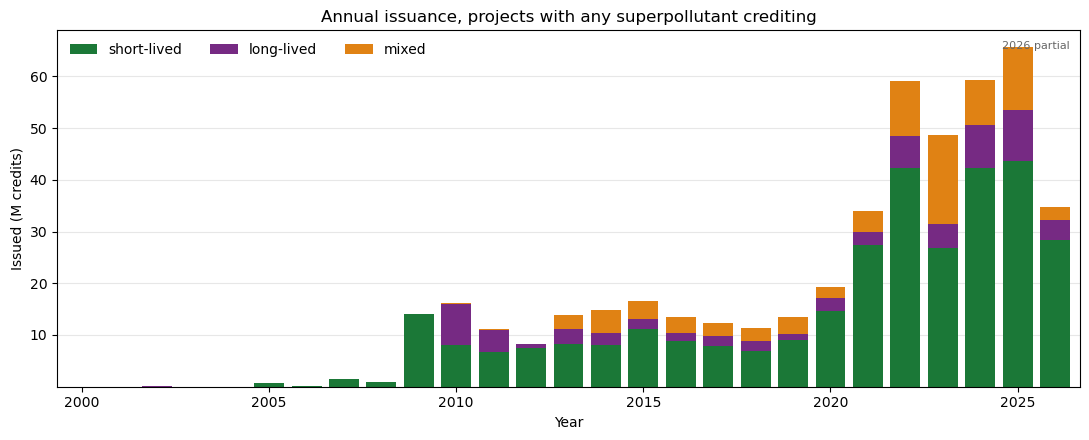

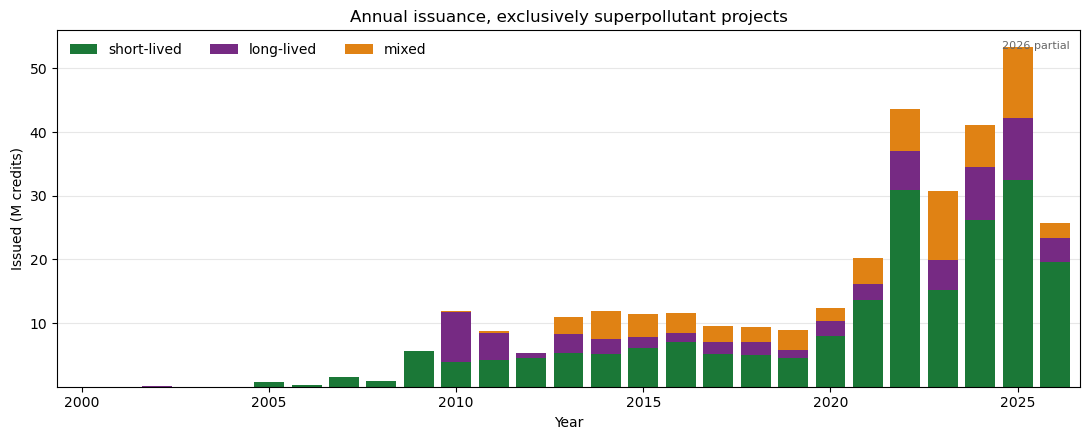

In [19]:
years = list(range(2000, 2027))
issuance_cols = [f'issued_{y}' for y in years]
SP_CLASSES = ['short-lived', 'long-lived', 'mixed']
colors = {'short-lived': '#1b7837', 'long-lived': '#762a83', 'mixed': '#e08214'}

def class_ts(mask):
    """year x class matrix of issuance for the masked subset."""
    return (
        vcm_df[mask]
        .groupby('sp_classes')[issuance_cols].sum()
        .rename(columns=lambda c: int(c.split('_')[1]))
        .reindex(SP_CLASSES)
        .fillna(0)
        .T
    )

def stacked_bar(ts, title, note):
    fig, ax = plt.subplots(figsize=(11, 4.5))
    bottom = np.zeros(len(ts))
    x = ts.index.to_numpy()
    for cls in SP_CLASSES:
        vals = (ts[cls] / 1e6).to_numpy()
        ax.bar(x, vals, bottom=bottom, label=cls, color=colors[cls], width=0.8)
        bottom += vals
    ax.set_ylabel('Issued (M credits)')
    ax.set_xlabel('Year')
    ax.set_title(title)
    ax.legend(frameon=False, ncol=3)
    ax.grid(axis='y', alpha=0.3)
    ax.set_axisbelow(True)
    ax.margins(x=0.01)
    ax.annotate(note, xy=(0.99, 0.97), xycoords='axes fraction',
                ha='right', va='top', fontsize=8, color='#666')
    plt.tight_layout()
    plt.show()

has_ts  = class_ts(has_sp)
only_ts = class_ts(only_sp)

# totals should reconcile to the summary table
assert np.isclose(has_ts.to_numpy().sum(),  vcm_df.loc[has_sp,  'total_issued'].sum())
assert np.isclose(only_ts.to_numpy().sum(), vcm_df.loc[only_sp, 'total_issued'].sum())

stacked_bar(has_ts,
            'Annual issuance, projects with any superpollutant crediting',
            '2026 partial')
stacked_bar(only_ts,
            'Annual issuance, exclusively superpollutant projects',
            '2026 partial')

In [20]:
tbl = only_ts.copy()
tbl['total'] = tbl.sum(axis=1)
tbl['cumulative_total'] = tbl['total'].cumsum()
tbl['cumulative_pct'] = 100 * (tbl['cumulative_total'] / tbl['total'].sum())
tbl.round(2)

sp_classes,short-lived,long-lived,mixed,total,cumulative_total,cumulative_pct
2000,0,0,0,0,0,0
2001,0,0,0,0,0,0
2002,0,"125,000",0,"125,000","125,000",0
2003,0,0,0,0,"125,000",0
2004,500,0,0,500,"125,500",0
2005,"668,510",0,0,"668,510","794,010",0
2006,"229,061",0,0,"229,061","1,023,071",0
2007,"1,506,410",0,0,"1,506,410","2,529,481",1
2008,"864,015",0,0,"864,015","3,393,496",1
2009,"5,615,121",0,0,"5,615,121","9,008,617",3


## Plotting functions

Plots to get at the following questions by superpollutant class (created with help from Claude): 
- Do certain protocols or projects dominate credit issuance — cumulatively, or during recent years?
- Do certain protocols or projects dominate credit retirement — cumulatively, or during recent years?
- What's the composition of the SLCP credit backstock (protocols / projects)? What vintage years do those credits represent? Are people buying from those protocols and projects? 

In [21]:
_BASE = ['#1b7837', '#762a83', '#e08214', '#2166ac', '#b2182b', '#5aae61',
         '#9970ab', '#f1a340', '#67a9cf', '#d6604d']
_EXTRA = [matplotlib.colors.to_hex(plt.get_cmap('tab20')(i)) for i in range(20)]
_POOL = _BASE + [c for c in _EXTRA if c not in _BASE]
OTHER = 'All other protocols'

def _stack(ts, top, other=OTHER):
    top = [c for c in top if c in ts.columns]
    d = ts[top].copy()
    rest = ts.drop(columns=top)
    d[other] = rest.sum(axis=1) if len(rest.columns) else 0.0
    return d.div(d.sum(axis=1), axis=0)

def short(s, n=70):
    return s if len(s) <= n else s[:n].rstrip() + '…'

def stacked_shares(df, start, end, top_n, class_label='',
                   shared_protocols=True, rank_by='issued', colors=None):
    PANELS = [('issued',  'credits issued by year'),
              ('retired', 'credits retired by year')]
    LEGEND_NCOL, LEGEND_FONTSIZE = 2, 11

    def _ts(prefix):                                   # now closes over df/start/end
        cols = [f'{prefix}_{y}' for y in range(start, end + 1)]
        return (df.groupby('protocol')[cols].sum()
                  .rename(columns=lambda c: int(c.rsplit('_', 1)[1])).T)

    ts_by_panel = {p: _ts(p) for p, _ in PANELS}

    if shared_protocols:
        named = ts_by_panel[rank_by].sum().nlargest(top_n).index.tolist()
        top_by_panel = {p: named for p, _ in PANELS}
    else:
        top_by_panel = {p: ts_by_panel[p].sum().nlargest(top_n).index.tolist()
                        for p, _ in PANELS}
        named = []
        for p, _ in PANELS:
            for x in top_by_panel[p]:
                if x not in named:
                    named.append(x)
        top_by_panel = {p: [x for x in named if x in top_by_panel[p]] for p, _ in PANELS}

    COLORS = dict(colors) if colors else {}            
    for i, p in enumerate(named):
        COLORS.setdefault(p, _POOL[i % len(_POOL)])
    COLORS[OTHER] = '#bdbdbd'

    fig, axes = plt.subplots(len(PANELS), 1, figsize=(13, 3.4 * len(PANELS)),
                             sharex=True, squeeze=False)
    axes = axes.ravel()
    for ax, (prefix, lab) in zip(axes, PANELS):
        sh = _stack(ts_by_panel[prefix], top_by_panel[prefix])
        ax.stackplot(sh.index.to_numpy(), np.nan_to_num(sh.to_numpy().T),
                     colors=[COLORS[c] for c in sh.columns], alpha=0.85)
        ax.set_ylim(0, 1)
        ax.margins(x=0.01)
        ax.set_ylabel('Share of credits', fontsize=9)
        ax.set_title(f'{lab} — top {top_n} protocols')
        ax.xaxis.set_major_locator(MaxNLocator(integer=True))

    handles = [plt.Rectangle((0, 0), 1, 1, color=COLORS[p]) for p in named + [OTHER]]
    fig.legend(handles, [short(p) for p in named + [OTHER]],
               loc='upper center', bbox_to_anchor=(0.5, -0.01), ncol=LEGEND_NCOL,
               frameon=False, fontsize=LEGEND_FONTSIZE, handlelength=1.4,
               handleheight=1.0, labelspacing=0.7, columnspacing=1.8)
    axes[-1].set_xlabel('Year')
    plt.tight_layout()
    plt.show()

    for prefix, _ in PANELS:
        others = [q for q, _ in PANELS if q != prefix]
        only = [p for p in top_by_panel[prefix]
                if not any(p in top_by_panel[o] for o in others)]
        

    return named, COLORS, ts_by_panel

In [22]:
def cum_snapshot(df, start, end, top_n, class_label='', colors=None,
                 legend_ncol=2, legend_fontsize=10):
    def _mat(prefix):
        cols = [f'{prefix}_{y}' for y in range(start, end + 1)]
        return (df.groupby('protocol')[cols].sum()
                  .rename(columns=lambda c: int(c.rsplit('_', 1)[1])).T)

    iss, ret = _mat('issued'), _mat('retired')
    cum_named = iss.sum().nlargest(top_n).index.tolist()

    COLORS = dict(colors) if colors else {}
    for i, p in enumerate(cum_named):
        COLORS.setdefault(p, _POOL[i % len(_POOL)])
    COLORS[OTHER] = '#bdbdbd'

    def _with_other(m):
        keep = [c for c in cum_named if c in m.columns]
        d = m[keep].copy()
        d[OTHER] = m.drop(columns=keep).sum(axis=1)
        return d

    cum_i, cum_r = _with_other(iss.cumsum()), _with_other(ret.cumsum())

    fig, axes = plt.subplots(1, 2, figsize=(15, 5.5),
                             gridspec_kw={'width_ratios': [1.5, 1]})
    ax = axes[0]
    for c in cum_i.columns:
        ax.plot(cum_i.index.to_numpy(), (cum_i[c] / 1e6).to_numpy(),
                color=COLORS[c], lw=2, ls='--' if c == OTHER else '-')
    ax.set_xlabel('Year')
    ax.set_ylabel('Cumulative issued (M credits)')
    ax.set_title(f'{class_label}{": " if class_label else ""}cumulative issuance by protocol')
    ax.grid(alpha=0.3)
    ax.margins(x=0.01)
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))

    ax2 = axes[1]
    issued  = cum_i.iloc[-1] / 1e6
    retired = (cum_r.iloc[-1] / 1e6).reindex(issued.index).fillna(0)
    order = issued.sort_values().index
    issued, retired = issued[order], retired[order]
    ypos = np.arange(len(order))

    ax2.barh(ypos, issued.to_numpy(),  color=[COLORS[c] for c in order], alpha=0.30)
    ax2.barh(ypos, retired.to_numpy(), color=[COLORS[c] for c in order], alpha=0.95)
    ax2.set_yticks(ypos)
    ax2.set_yticklabels([short(i, 44) for i in order], fontsize=8)
    for i, (iv, rv) in enumerate(zip(issued.to_numpy(), retired.to_numpy())):
        ax2.text(iv * 1.02, i, f'{100 * rv / iv:.0f}%' if iv else '—',
                 va='center', fontsize=8, color='0.3')
    ax2.set_xlabel('Cumulative issuance (M)')
    ax2.set_title(f'Remaining (pale) vs retired (solid), through {end}')
    ax2.grid(axis='x', alpha=0.3)
    ax2.margins(x=0.14)

    handles = [plt.Rectangle((0, 0), 1, 1, color=COLORS[p]) for p in cum_named + [OTHER]]
    handles += [plt.Rectangle((0, 0), 1, 1, color='0.45', alpha=0.30),
                plt.Rectangle((0, 0), 1, 1, color='0.45', alpha=0.95)]
    labels = [short(p) for p in cum_named + [OTHER]] + ['(pale) remaining', '(solid) retired']
    fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, -0.01),
               ncol=legend_ncol, frameon=False, fontsize=legend_fontsize,
               handlelength=1.6, labelspacing=0.6, columnspacing=1.8)
    plt.tight_layout()
    plt.show()

In [23]:
def outstanding_credits(df, start, end, named, colors=None,
                        class_label='', legend_ncol=2, legend_fontsize=10,
                        label_chars=70):
    cols = [f'remaining_vintage_{y}' for y in range(start, end + 1)]
    rem = (df.groupby('protocol')[cols].sum()
             .rename(columns=lambda c: int(c.rsplit('_', 1)[1])).T)

    COLORS = dict(colors) if colors else {}
    for i, p in enumerate(named):
        COLORS.setdefault(p, _POOL[i % len(_POOL)])
    COLORS[OTHER] = '#bdbdbd'

    stack_order = [p for p in named if p in rem.columns]
    plot_df = rem[stack_order].copy()                      # not `df`
    rest = rem.drop(columns=stack_order)
    plot_df[OTHER] = rest.sum(axis=1) if len(rest.columns) else 0.0
    plot_df = plot_df / 1e6

    fig, ax = plt.subplots(figsize=(13, 5.5))
    bottom = np.zeros(len(plot_df))
    for c in plot_df.columns:
        ax.bar(plot_df.index.to_numpy(), plot_df[c].to_numpy(), bottom=bottom,
               color=COLORS[c], width=0.82, edgecolor='white', linewidth=0.4)
        bottom += plot_df[c].to_numpy()

    ax.set_xlabel('Vintage year')
    ax.set_ylabel('Credits remaining (M)')
    ax.set_title(f'{class_label}{" " if class_label else ""}credits still outstanding, '
                 f'by vintage year and protocol')
    ax.grid(axis='y', alpha=0.3)
    ax.set_axisbelow(True)
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))
    ax.margins(x=0.01)
    ax.text(0.99, 0.95, f'total outstanding: {plot_df.sum().sum():,.1f}M',
            transform=ax.transAxes, ha='right', va='top', fontsize=9, color='0.3')

    handles = [plt.Rectangle((0, 0), 1, 1, color=COLORS[p]) for p in stack_order + [OTHER]]
    fig.legend(handles, [short(p, label_chars) for p in stack_order + [OTHER]],
               loc='upper center', bbox_to_anchor=(0.5, -0.01), ncol=legend_ncol,
               frameon=False, fontsize=legend_fontsize, handlelength=1.4,
               labelspacing=0.6, columnspacing=1.8)
    plt.tight_layout()
    plt.show()

    # vintage-age profile of the outstanding stock
    tot = plot_df.sum(axis=1)
    age = pd.DataFrame({'remaining_M': tot,
                        'age_yrs': end - tot.index,
                        'pct': 100 * tot / tot.sum()})
    print(f'weighted mean vintage age: '
          f'{np.average(age["age_yrs"], weights=age["remaining_M"]):.1f} years')

## Unpacking short-lived trends by protocol

Let's dig into the short-lived credit class. Given the short atmmospheric lifetime of the associated gas fluxes, this credit class is the most interesting from the perspective of temporal mismatches in offsetting, and how they might affect temperature outcomes. 

Takeaways: Landfill credits from [CAR U.S. Landfill Protocol](https://climateactionreserve.org/how/protocols/waste/us-landfill/) and [ACC001](https://cdm.unfccc.int/methodologies/DB/JPYB4DYQUXQPZLBDVPHA87479EMY9M) dominate all-time SLCP action, but a few recent growth categories seem worth watching.
- [ACR Transition to Advanced Formulation Blowing Agents in Foam Manufacturing and Use](https://acrcarbon.org/wp-content/uploads/2023/03/ACR-FBA-v3.0.pdf) saw a rapid rise in use, the timing of which looks like it might correspond with the development of version 2 of that protocol in 2018. ACR deactivated the protocol at the end of 2024, so I wouldn’t expect it to continue to play a growing role — but it will be interesting to see if there’s sustained demand for the outstanding credits. The bulk of projects came online 2016-2023. Notably, these credits are awarded for using a lower GWP blowing agent in the production of foam. Common baseline blowing agents per the protocol include HFC-152a, HFC-365mfc, HFC245fa, and HFC134a — which are pretty short lived (1.5-13.4 years).
- [AM0023 for leak detection and repair in gas systems](https://cdm.unfccc.int/methodologies/DB/PZN9ZCTGF3KHFH0W21NY0NYL6X5CIR)is a CDM protocol that was last updated in 2011 that’s now seemingly booming under Verra. It has only 9 credited projects under it, seven of which are located in Bangladesh, which I believe has a state-owned oil and gas sector. As an aside, it looks like some of these credits are in [BP’s carbon credit portfolio](https://www.bp.com/en_gb/carbon-connect/home/our-carbon-credit-portfolio/our-current-portfolio/titas-gas-methane-leak-reduction.html). 
- [ACR Plugging of Orphaned Oil and Gas (OOG) Wells](https://acrcarbon.org/methodology/plugging-orphaned-oil-and-gas-wells-2/) is actively being updated, but the first version has a notable spike in use. 

In [24]:
sl = vcm_df[has_sp & (vcm_df['sp_classes'] == 'short-lived')]
year_start = 2000
year_end = 2025
top_n = 15

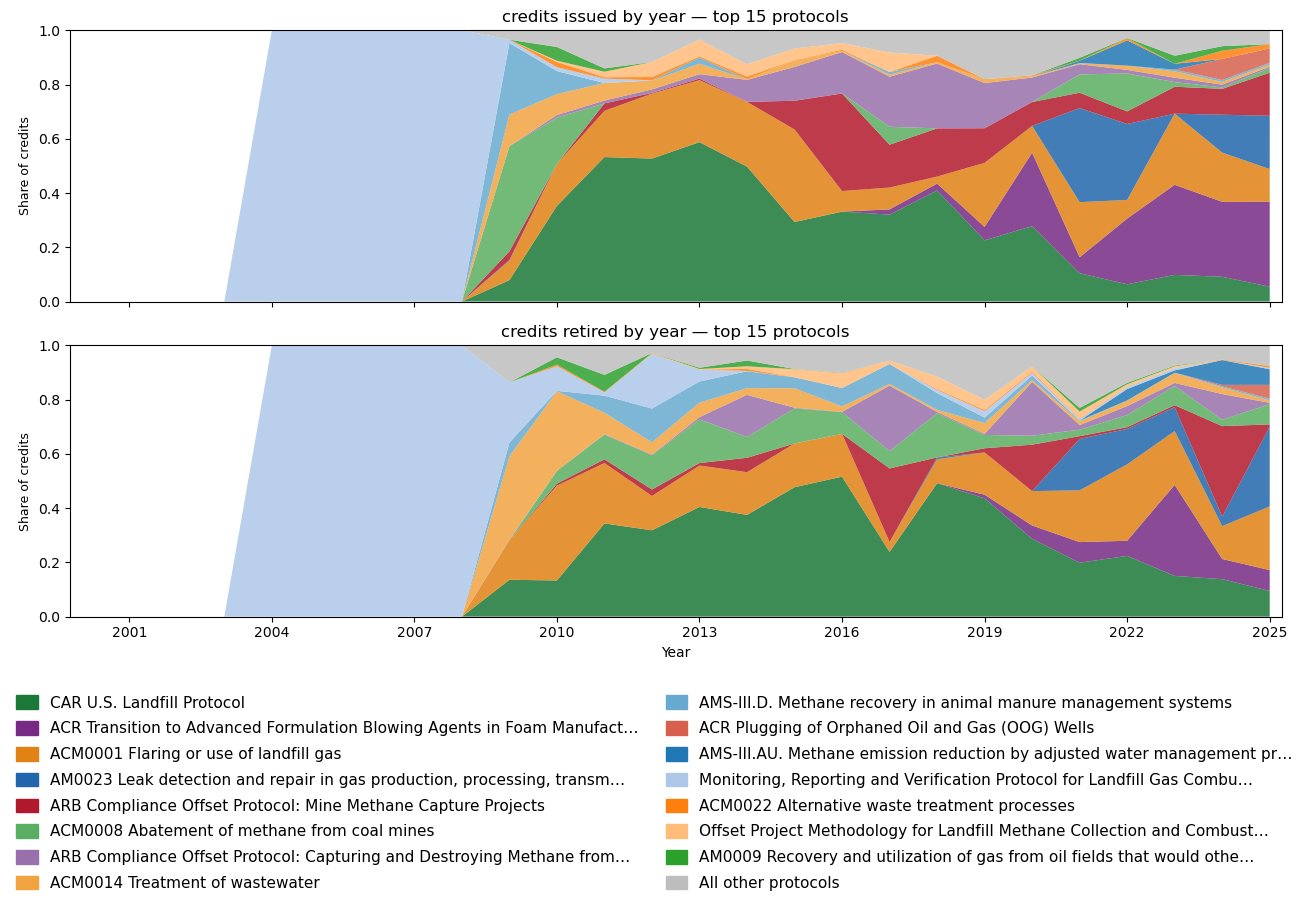

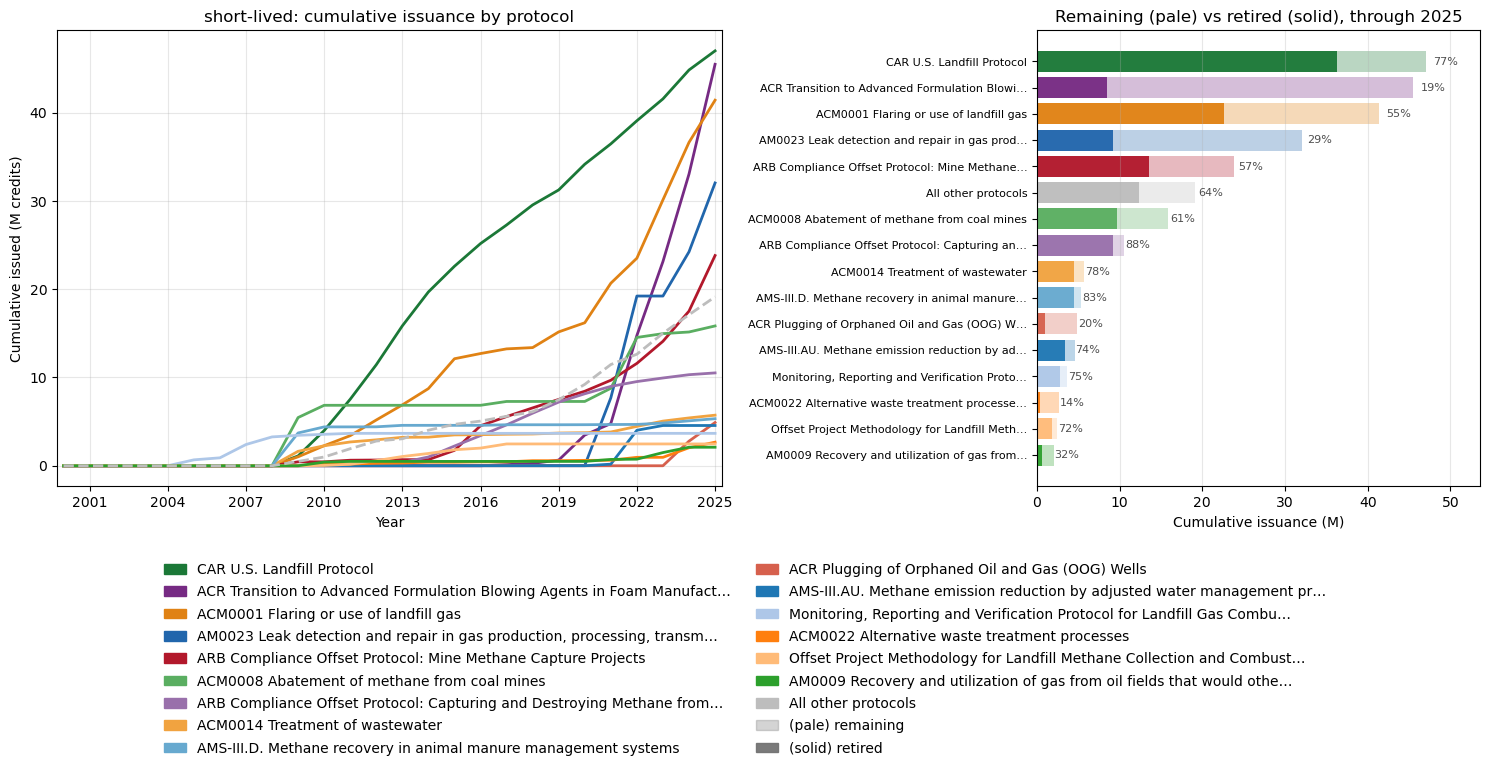

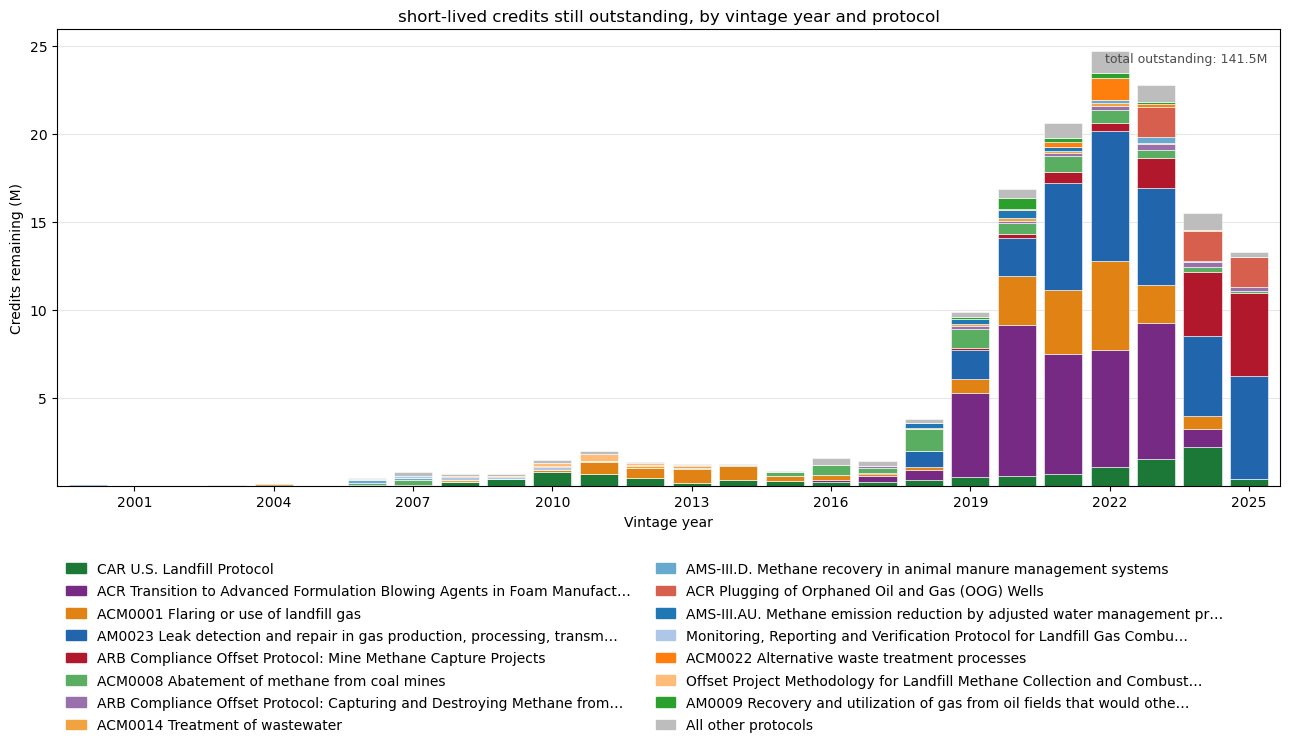

weighted mean vintage age: 4.0 years


In [25]:
named, colors, ts = stacked_shares(sl, year_start, year_end, top_n, class_label='short-lived')
cum_snapshot(sl, year_start, year_end, top_n, class_label='short-lived', colors=colors)
outstanding_credits(sl, year_start, year_end, named=named, colors=colors, class_label='short-lived')

## Unpacking long-lived trends by protocol

Takeaways: 
- Huge recent surge of credits under the [CAR U.S. Adipic Acid Production protocol](https://climateactionreserve.org/how/protocols/industrial/adipic-acid-production/), which accounts for essentially the entire recent growth of the long-lived class. Interestingly, it’s entirely driven by a single project ([CAR1480](https://thereserve2.apx.com/mymodule/reg/TabDocuments.asp?r=111&ad=Prpt&act=update&type=PRO&aProj=pub&tablename=doc&id1=1480)), the only credited project under the protocol. All told, it works out to more than a third of all long-lived superpollutant issuances from one project in 5 years!
- [ACR Destruction of Ozone Depleting Substances from International Sources](https://acrcarbon.org/methodology/destruction-of-ozone-depleting-substances-from-international-sources/) is also on the upswing. 

In [26]:
ll = vcm_df[has_sp & (vcm_df['sp_classes'] == 'long-lived')]
year_start = 2005
year_end = 2025
top_n = 6

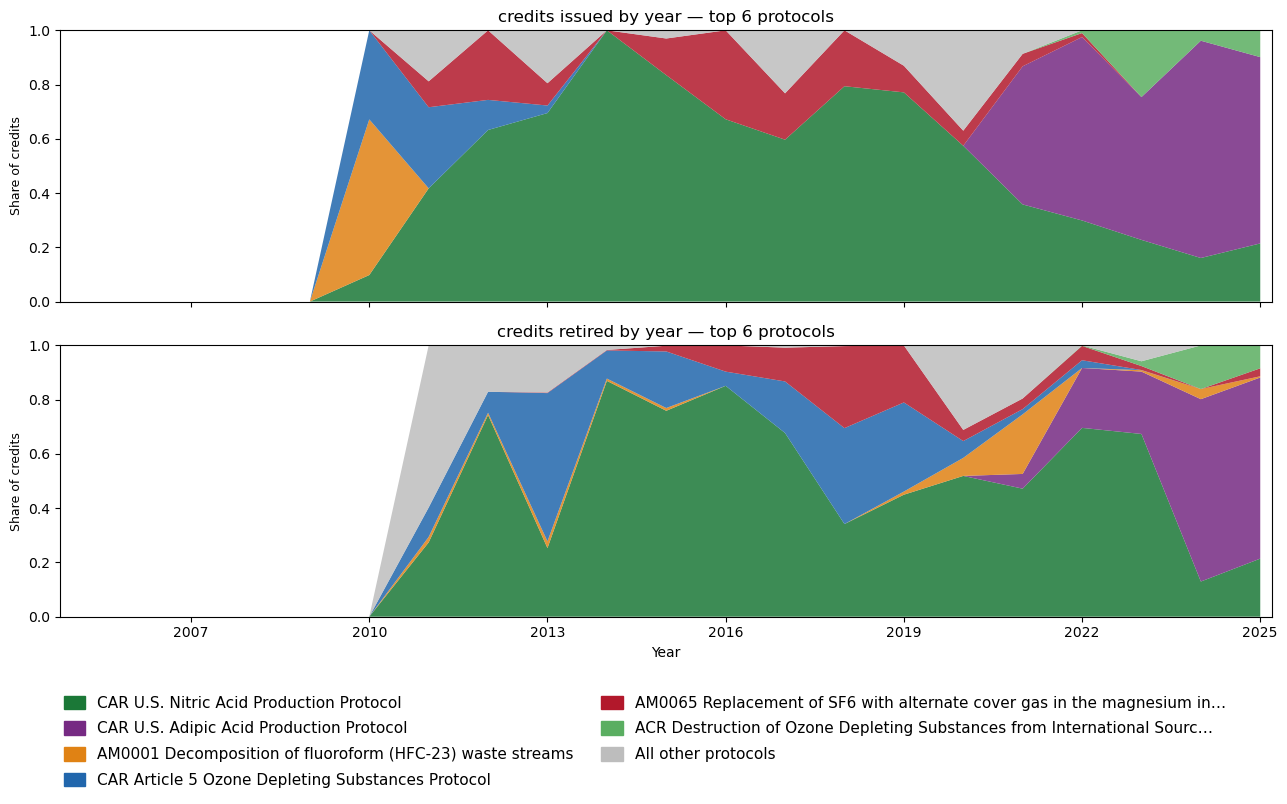

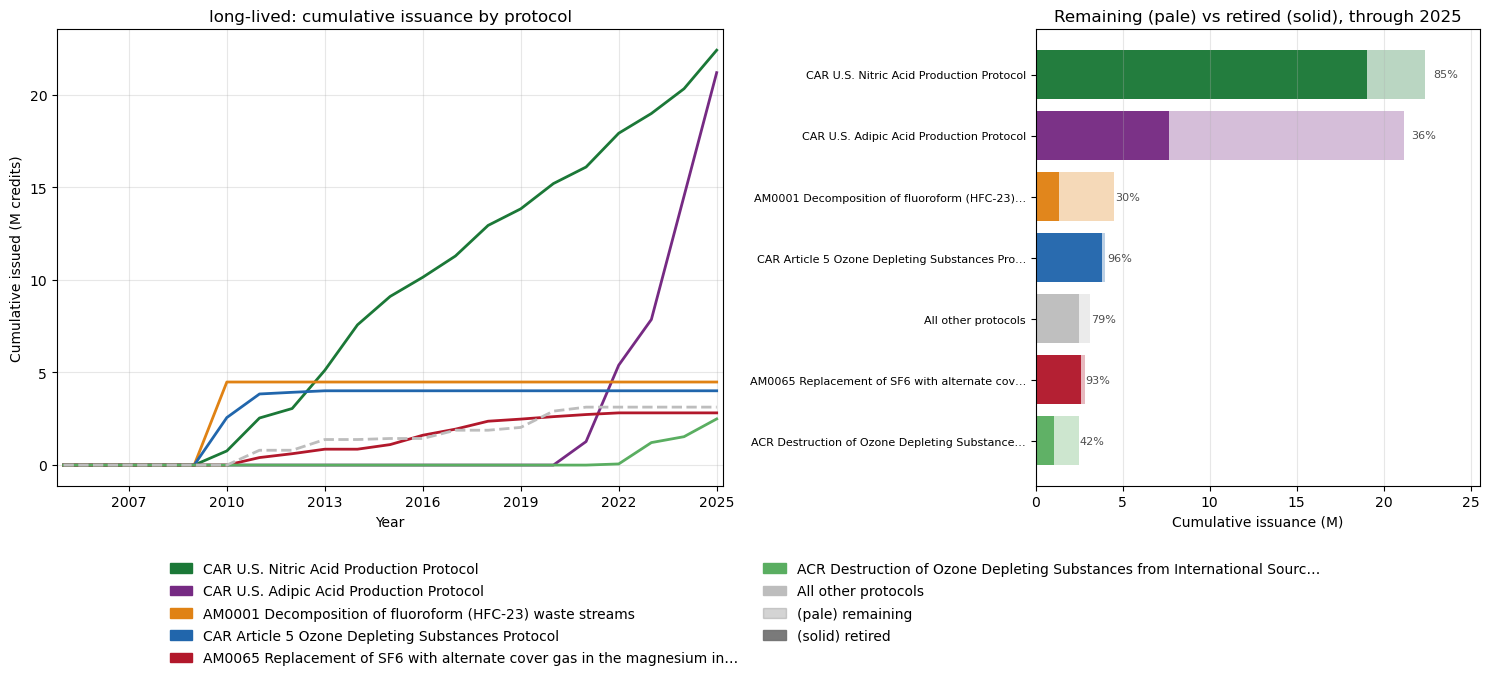

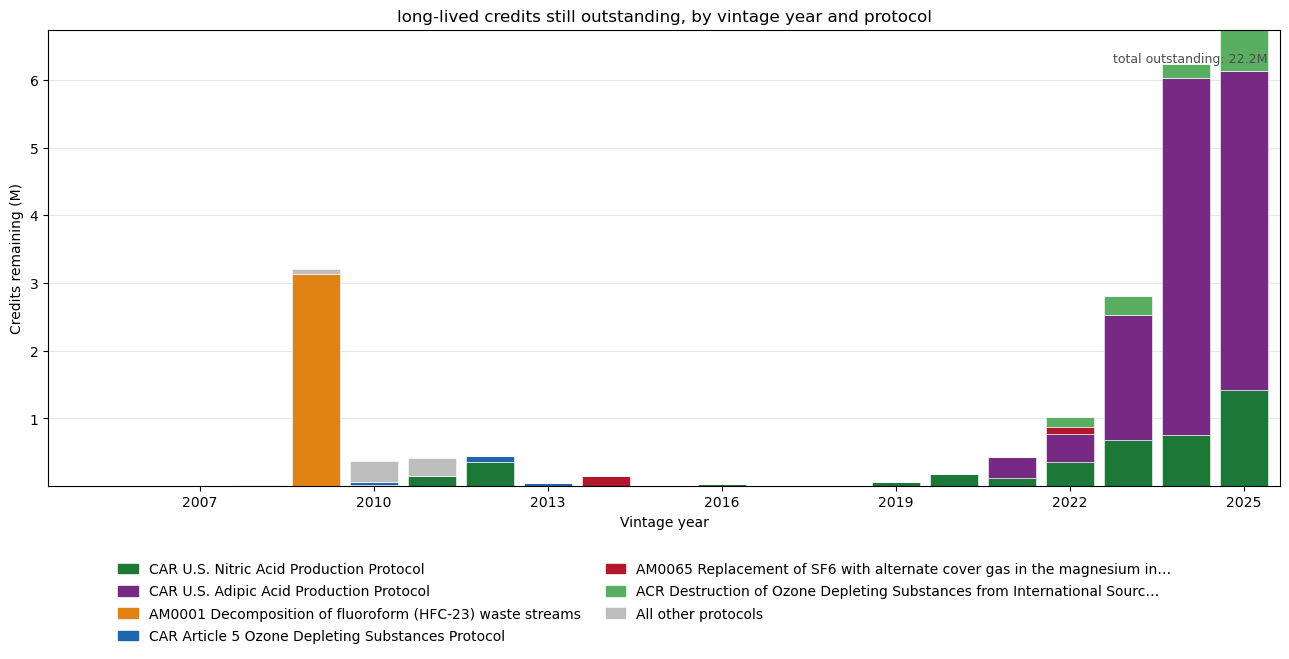

weighted mean vintage age: 4.0 years


In [27]:
named, colors, ts = stacked_shares(ll, year_start, year_end, top_n, class_label='long-lived')
cum_snapshot(ll, year_start, year_end, top_n, class_label='long-lived', colors=colors)
outstanding_credits(ll, year_start, year_end, named=named, colors=colors, class_label='long-lived')

## Exploring protocol level trends

At the protocol level, it can be useful to get a quick picture of the level of concentration in particular projects or by particular developers. In this section, you can specify the protocol and get a quick peek. 

Check out `CAR U.S. Adipic Acid Production Protocol` for an example of full concentration, or `CAR U.S. Landfill Protocol` for an example of more distributed activity. 

In [28]:
protocol = 'CAR U.S. Landfill Protocol'
subset = vcm_df[vcm_df['protocol'] == protocol]

In [29]:
PLACEHOLDERS = {'Multiple Proponents', 'Converted from other GHG program',
                'Not provided', 'Other', ''}

def concentration_profile(subset, label='', by=('project_id', 'developer', 'region'),
                          value='total_issued', top_k=5, extra_cols=('project_name',)):
    """At-a-glance concentration of a value across projects / developers / regions."""
    total = subset[value].sum()
    print(f'{label or "subset"}: {len(subset):,} projects | {total/1e6:,.2f}M {value}\n')

    def _clean(s, dim):
        if dim == 'developer':                      # placeholders aren't real entities
            s = s[~s[dim].fillna('').str.strip().isin(PLACEHOLDERS)]
        return s

    rows, tops = [], {}
    for dim in by:
        s = _clean(subset.copy(), dim)
        key = s[dim].fillna('(missing)').astype(str).str.strip()
        g = s.groupby(key)[value].sum()
        g = g[g > 0].sort_values(ascending=False)
        if g.empty:
            continue
        share = g / total
        rows.append(pd.Series({
            'n_units':     len(g),
            'covered_pct': 100 * share.sum(),
            'top1_pct':    100 * share.iloc[:1].sum(),
            'top3_pct':    100 * share.iloc[:3].sum(),
            'top5_pct':    100 * share.iloc[:5].sum(),
            'n_for_50pct': int(((g / g.sum()).cumsum() < 0.5).sum() + 1),
        }, name=dim))

        t = (s.groupby(key)
               .agg(**{value: (value, 'sum'), 'n_projects': (value, 'size')})
               .nlargest(top_k, value))
        t['pct'] = 100 * t[value] / total
        # for project-level, show the name alongside the id
        for c in extra_cols:
            if dim == 'project_id' and c in s.columns:
                t[c] = s.groupby(key)[c].first()
        tops[dim] = t

    display(pd.DataFrame(rows).round(1))

    for dim, t in tops.items():
        print(f'\n--- top {min(top_k, len(t))} by {dim} ---')
        display(t.round(1))

concentration_profile(subset, label=protocol)

CAR U.S. Landfill Protocol: 130 projects | 48.18M total_issued



,n_units,covered_pct,top1_pct,top3_pct,top5_pct,n_for_50pct
project_id,124,100,4,12,19,20
developer,85,100,15,33,41,9
region,1,100,100,100,100,1



--- top 5 by project_id ---


,total_issued,n_projects,pct,project_name
project_id,,,,
CAR674,"2,176,702",1,4,"Oneida Herkimer Landfill Ava, NY"
CAR400,"2,053,918",1,4,South Jordan Landfill Gas Destruction Project
CAR621,"1,684,325",1,4,Kimble Sanitary Landfill Gas Project
CAR443,"1,530,509",1,3,South Kent Landfill Gas to Energy Project
CAR635,"1,521,320",1,3,Hancock County Landfill Gas Collection Project



--- top 5 by developer ---


,total_issued,n_projects,pct
developer,,,
"Anew Environmental, LLC","7,048,578",12,15
"3Degrees Group, Inc","5,885,291",11,12
Sustainable Energy Solutions LLC,"3,099,831",4,6
Oneida Herkimer Solid Waste Authority,"2,176,702",1,4
Kimble Company,"1,684,325",1,4



--- top 1 by region ---


,total_issued,n_projects,pct
region,,,
North America,"48,182,125",130,100


## Exporting timeseries

For the purposes of FaIR analysis, we'd like to export timeseries data approximating when when superpollutant fluxes due to VCM activity — and potential justified emissions associated with the superpollutant credit retirement — took place. Specifically, we want: 

- `vcm_methane_credit_timeseries.csv`
    - issuance by vintage, retirement by vintage, and retirement by year for credits representing methane fluxes
    - lower bound (only_superpollutant = True, gases = CH4, no compliance protocols) 
    - upper bound (has_superpollutant = True, gases include CH4, class = "short-lived" OR "mixed"; i.e. include projects that bundle  slcp and non-slcp protocols,  projects that may get credit for reducing fossil CO2 avoidance alongside methane reductions (e.g. biogas --> energy), and projects that credit a mix of superpollutant with different lifetimes (e.g. methane + N2O reductions for manure management)

- `vcm_{class}_credit_timeseries.csv`
    - one file each for short-lived and long-lived
    - issuance by vintage, retirement by vintage, and retirement by year 
    - lower bound (only_superpollutant = True, no compliance protocols, class = {} OR "mixed")  
    - upper bound (has_superpollutant = True, class = {}) 

- `vcm_credit_timeseries.csv`

In [30]:
export_years = list(range(1996, 2027))
out_path = '../timeseries-data/output-data/'
metrics = {'issued_vintage':  'issued_vintage_{}',
           'retired_vintage': 'retired_vintage_{}',
           'retired_year':    'retired_{}'}
cols = {m: [p.format(y) for y in export_years] for m, p in metrics.items()}

# create one column per metric, indexed by year
def timeseries(mask, bound):
    sub = vcm_df[mask]
    return pd.DataFrame(
        {f'{m}_{bound}': sub[cs].sum().to_numpy() for m, cs in cols.items()},
        index=pd.Index(export_years, name='year'),
    )
not_compliance = vcm_df['arb_wa'] == 'No'

In [31]:
# methane credit timeseries
has_ch4 = vcm_df['gases'].map(lambda v: 'CH4' in v if isinstance(v, (list, set, tuple)) else False)
ch4_lower_mask = only_sp & has_ch4 & not_compliance & (vcm_df['sp_classes'] == 'short-lived')
ch4_upper_mask = has_sp & has_ch4 & vcm_df['sp_classes'].isin(['short-lived', 'mixed'])

methane = pd.concat([
    timeseries(ch4_lower_mask, 'lower'),
    timeseries(ch4_upper_mask, 'upper'),
], axis=1)

methane.to_csv(out_path + 'vcm_methane_credit_timeseries.csv')
print(methane.sum().round(0))
methane

issued_vintage_lower    123,037,233
retired_vintage_lower    65,751,646
retired_year_lower       65,751,646
issued_vintage_upper    280,427,278
retired_vintage_upper   157,545,601
retired_year_upper      157,545,601
dtype: float64


,issued_vintage_lower,retired_vintage_lower,retired_year_lower,issued_vintage_upper,retired_vintage_upper,retired_year_upper
year,,,,,,
1996,0,0,0,0,0,0
1997,0,0,0,0,0,0
1998,"48,826",330,0,"48,826",330,0
1999,"74,895","6,547",0,"74,895","6,547",0
2000,"116,696","3,040",0,"126,863","13,207",0
2001,"208,012","171,671",0,"313,506","277,155",0
2002,"253,233","227,228",0,"594,713","567,482",0
2003,"618,975","499,585",0,"872,153","747,763",0
2004,"804,373","749,031",407,"1,194,830","1,018,477",407


In [32]:
# short-lived credit timeseries
sl_lower_mask = only_sp & not_compliance & (vcm_df['sp_classes'] == 'short-lived')
sl_upper_mask = has_sp  & vcm_df['sp_classes'].isin(['short-lived', 'mixed'])

sl = pd.concat([
    timeseries(sl_lower_mask, 'lower'),
    timeseries(sl_upper_mask, 'upper'),
], axis=1)

sl.to_csv(out_path + 'vcm_sl_credit_timeseries.csv')
print(sl.sum().round(0))
sl

issued_vintage_lower    168,849,894
retired_vintage_lower    74,922,099
retired_year_lower       74,922,099
issued_vintage_upper    405,518,642
retired_vintage_upper   210,532,615
retired_year_upper      210,532,615
dtype: float64


,issued_vintage_lower,retired_vintage_lower,retired_year_lower,issued_vintage_upper,retired_vintage_upper,retired_year_upper
year,,,,,,
1996,0,0,0,0,0,0
1997,0,0,0,0,0,0
1998,"48,826",330,0,"48,826",330,0
1999,"74,895","6,547",0,"74,895","6,547",0
2000,"116,696","3,040",0,"126,863","13,207",0
2001,"208,012","171,671",0,"313,506","277,155",0
2002,"253,233","227,228",0,"594,713","567,482",0
2003,"618,975","499,585",0,"872,153","747,763",0
2004,"804,373","749,031",407,"1,194,830","1,018,477",407


In [33]:
# long-lived credit timeseries
ll_lower_mask = only_sp & not_compliance & (vcm_df['sp_classes'] == 'long-lived')
ll_upper_mask = has_sp  & vcm_df['sp_classes'].isin(['long-lived', 'mixed'])

ll = pd.concat([
    timeseries(ll_lower_mask, 'lower'),
    timeseries(ll_upper_mask, 'upper'),
], axis=1)

ll.to_csv(out_path + 'vcm_ll_credit_timeseries.csv')
print(ll.sum().round(0))
ll

issued_vintage_lower     64,473,760
retired_vintage_lower    40,828,221
retired_year_lower       40,828,221
issued_vintage_upper    144,388,188
retired_vintage_upper    84,688,647
retired_year_upper       84,688,647
dtype: float64


,issued_vintage_lower,retired_vintage_lower,retired_year_lower,issued_vintage_upper,retired_vintage_upper,retired_year_upper
year,,,,,,
1996,0,0,0,0,0,0
1997,0,0,0,0,0,0
1998,0,0,0,0,0,0
1999,0,0,0,0,0,0
2000,0,0,0,0,0,0
2001,"125,000",0,0,"125,000",0,0
2002,0,0,0,0,0,0
2003,0,0,0,0,0,0
2004,0,0,0,0,0,0


In [34]:
# full vcm credit timeseries
vcm_lower_mask = not_compliance
vcm_upper_mask = pd.Series(True, index=vcm_df.index)

vcm = pd.concat([
    timeseries(vcm_lower_mask, 'lower'),
    timeseries(vcm_upper_mask, 'upper'),
], axis=1)

vcm.to_csv(f'{out_path}/vcm_credit_timeseries.csv')
print(vcm.sum().round(0))
vcm

issued_vintage_lower    2,385,921,334
retired_vintage_lower   1,350,020,118
retired_year_lower      1,350,020,118
issued_vintage_upper    2,654,958,148
retired_vintage_upper   1,561,901,935
retired_year_upper      1,561,901,935
dtype: float64


,issued_vintage_lower,retired_vintage_lower,retired_year_lower,issued_vintage_upper,retired_vintage_upper,retired_year_upper
year,,,,,,
1996,764,0,0,764,0,0
1997,"1,605",0,0,"1,605",0,0
1998,"50,724",330,0,"50,724",330,0
1999,"77,883","6,547",0,"77,883","6,547",0
2000,"1,122,245","430,153",0,"1,122,245","430,153",0
2001,"1,374,183","1,107,505",0,"1,374,183","1,107,505",0
2002,"1,765,965","1,474,173",0,"1,771,753","1,479,961",0
2003,"5,170,441","2,396,514",0,"5,187,160","2,413,233",0
2004,"8,176,291","3,850,216",407,"8,210,367","3,884,292",407
